In [106]:
import pandas as pd
import scipy.constants as const
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from scipy.optimize import curve_fit
from sigfig import round


import numpy as np


def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty


In [107]:
voltages_df = pd.read_csv("Stopping Voltages 400.csv")
voltages_df.drop(columns=["filter"], inplace=True)

In [108]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


def find_data_from_spectrometer(filepath):
    df = pd.read_csv(filepath, header=0, names=["wavelength", "intensity"])
    max_intensity = df["intensity"].max()
    max_index = df["intensity"].idxmax()
    max_wavelength = df["wavelength"].iloc[max_index]

    x_data = df["wavelength"]
    y_data = df["intensity"]

    popt, pcov = curve_fit(
        gaussian, x_data, y_data, p0=[max_intensity, x_data[max_index], np.std(x_data)]
    )

    # Generate smooth x values for the fit curve
    # ax1.plot(x_fit, y_fit, "r-", label="Gaussian Fit")

    mu, sigma = popt[1], abs(popt[2])
    lower_bound = mu - sigma
    upper_bound = mu + sigma

    width = upper_bound - lower_bound
    half_width = width / 2

    return {
        "df": df,
        "max_intensity": max_intensity,
        "max_wavelength": max_wavelength,
        "center": mu,
        "width": width,
        "half_width": half_width,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    }


wavelength_labels = [
    # 400,
    455,
    470,
    505,
    525,
    570,
    590,
    604,
    626,
    640,
]
file_paths = [f"spectrometer/{label}.csv" for label in wavelength_labels]

spect_res = []
for i, filepath in enumerate(file_paths):
    result = find_data_from_spectrometer(filepath)
    result.update({"wavelength": wavelength_labels[i]})
    spect_res.append(result)
spect_df = pd.DataFrame(spect_res)
spect_df = spect_df.sort_values("wavelength")


df = pd.merge(spect_df, voltages_df, on="wavelength", how="inner")
df.rename(
    columns={"stopping_voltage_uncertainty": "stopping_voltage_unc"}, inplace=True
)

df["max_wavelength"], df["wavelength_unc"] = round_unc(
    spect_df["max_wavelength"], spect_df["half_width"]
)
df["stopping_voltage"], df["stopping_voltage_unc"] = round_unc(
    df["stopping_voltage"], df["stopping_voltage_unc"]
)

df["-e_delta_v"] = -const.e * (-df["stopping_voltage"])
df["c_over_lambda"] = const.c / (df["max_wavelength"] * 1e-9)

df["-e_delta_v_unc"] = const.e * df["stopping_voltage_unc"]
df["c_over_lambda_unc"] = np.abs(
    const.c / (df["max_wavelength"] * 1e-9) ** 2 * (df["wavelength_unc"] * 1e-9)
)

df["-e_delta_v"], df["-e_delta_v_unc"] = round_unc(
    df["-e_delta_v"], df["-e_delta_v_unc"]
)

df["c_over_lambda"], df["c_over_lambda_unc"] = round_unc(
    df["c_over_lambda"], df["c_over_lambda_unc"]
)

In [109]:
df.head()

,df,max_intensity,max_wavelength,center,width,half_width,lower_bound,upper_bound,wavelength,initial_current,stopping_voltage,stopping_voltage_unc,wavelength_unc,-e_delta_v,c_over_lambda,-e_delta_v_unc,c_over_lambda_unc
0,wavelength intensity 0 350 ...,923.71,438.0,436.885622,6.931332,3.465666,433.419956,440.351288,455,5.21,1.2635,0.0001,3.0,2.024350e-19,6.840000e+14,1.600000e-23,5.000000e+12
1,wavelength intensity 0 350 ...,3781.90,466.0,471.174059,26.222154,13.111077,458.062982,484.285136,470,5.21,1.1400,0.0001,13.0,1.826480e-19,6.430000e+14,1.600000e-23,1.800000e+13
2,wavelength intensity 0 350 ...,3285.43,506.0,507.851198,23.477717,11.738859,496.112339,519.590057,505,5.21,0.8612,0.0001,12.0,1.379790e-19,5.920000e+14,1.600000e-23,1.400000e+13
3,wavelength intensity 0 350 ...,2988.05,519.0,520.519002,27.413492,13.706746,506.812256,534.225748,525,5.21,0.8044,0.0001,14.0,1.288790e-19,5.780000e+14,1.600000e-23,1.600000e+13
4,wavelength intensity 0 350 ...,2788.01,569.0,569.730507,24.614969,12.307485,557.423023,582.037992,570,5.21,0.6306,0.0001,12.0,1.010330e-19,5.270000e+14,1.600000e-23,1.100000e+13


In [110]:
df.columns

Index(['df', 'max_intensity', 'max_wavelength', 'center', 'width',
       'half_width', 'lower_bound', 'upper_bound', 'wavelength',
       'initial_current', 'stopping_voltage', 'stopping_voltage_unc',
       'wavelength_unc', '-e_delta_v', 'c_over_lambda', '-e_delta_v_unc',
       'c_over_lambda_unc'],
      dtype='object')

In [111]:
def h(lamb, W, V_s):
    return lamb / const.c * (W + const.e * V_s)


def delta_h(W, e, Vs, delta_lambda, delta_W, delta_Vs, lamb, c):
    """
    Compute sh based on the expression:
        sh = sqrt(
            [(1/c * (W + e*Vs) * delta_lambda)**2 +
             [(lamb/c * delta_W)**2 +
             [(lamb/c * e * delta_Vs)**2]
        )
    """
    term1 = (1 / c) * (W + e * Vs) * delta_lambda
    term2 = (lamb / c) * delta_W
    term3 = (lamb / c) * e * delta_Vs

    return np.sqrt(term1**2 + term2**2 + term3**2)


W = 2.47e-19  # J
W_unc = 0.12e-19  # J

df["h"] = h(df["max_wavelength"] * 1e-9, W, df["stopping_voltage"])
df["h_unc"] = delta_h(
    W=W,
    e=const.e,
    Vs=df["stopping_voltage"],
    delta_lambda=df["wavelength_unc"] * 1e-9,
    delta_W=W_unc,
    delta_Vs=df["stopping_voltage_unc"],
    lamb=df["max_wavelength"] * 1e-9,
    c=const.c,
)

df["h"], df["h_unc"] = round_unc(df["h"], df["h_unc"])


In [112]:
df["stopping_voltage"]

0    1.2635
1    1.1400
2    0.8612
3    0.8044
4    0.6306
5    0.5669
6    0.4929
7    0.4073
8    0.3113
Name: stopping_voltage, dtype: float64

In [113]:
df[["h", "h_unc"]].to_csv("pointwise_h_values.csv", index=False)

In [119]:
mean = df["h"].mean()
std = df["h"].std(ddof=1)
sdom = std / np.sqrt(len(df))

# mean, sdom = round_unc(mean, sdom)

print(f"Mean: {mean} J·s")
print(f"Standard Deviation: {std} J·s")
print(f"Standard Deviation of the Mean: {sdom} J·s")

Mean: 6.5866666666666666e-34 J·s
Standard Deviation: 8.631338250816027e-36 J·s
Standard Deviation of the Mean: 2.877112750272009e-36 J·s


In [115]:
const.h

6.62607015e-34

In [116]:
(const.h - mean) / sdom

np.float64(1.3472465517241325)

In [117]:
mean - sdom

np.float64(6.558e-34)

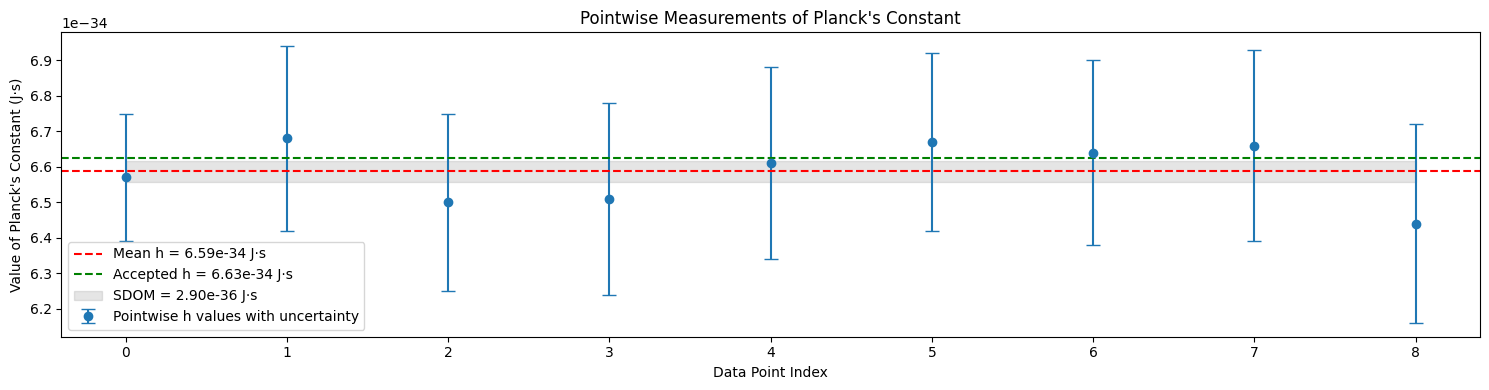

In [118]:
plt.figure(figsize=(15, 4))
plt.errorbar(
    df.index,
    df["h"],
    yerr=df["h_unc"],
    fmt="o",
    capsize=5,
    label="Pointwise h values with uncertainty",
)
plt.axhline(y=mean, color="r", linestyle="--", label=f"Mean h = {mean:.2e} J·s")
plt.axhline(
    y=const.h, color="g", linestyle="--", label=f"Accepted h = {const.h:.2e} J·s"
)
plt.fill_between(
    df.index,
    mean - sdom,
    mean + sdom,
    color="gray",
    alpha=0.2,
    label=f"SDOM = {sdom:.2e} J·s",
)
plt.xlabel("Data Point Index")
plt.ylabel("Value of Planck's Constant (J·s)")
plt.title("Pointwise Measurements of Planck's Constant")
plt.legend()
plt.tight_layout()
plt.savefig("pointwise_h_values.png")
plt.show()
